# Sprint 2 — Réseau de neurones & Évaluation
**Framework :** TensorFlow / Keras  |  **Tracking :** MLflow  |  **Dataset :** BRFSS 2015

---
## Sommaire
1. [Setup & imports](#1)
2. [Prétraitement (train / val / test)](#2)
3. [Architecture du réseau](#3)
4. [Entraînement](#4)
5. [Courbes d'entraînement](#5)
6. [Évaluation sur le test](#6)
7. [Analyse du seuil de décision](#7)
8. [Matrice de confusion](#8)
9. [MLflow — suivi des expériences](#9)


---
Pour demarer correctement le projet il faut récuperer tous les éléments de la branche "Sprint2" dans le dépo Github suivant :
https://github.com/Cromano57/BigData 

## 1. Setup & imports <a id='1'></a>

In [12]:
import sys, json, unicodedata
from pathlib import Path

PROJECT_ROOT = Path(unicodedata.normalize('NFC', str(Path().resolve().parent)))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow, mlflow.keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, f1_score
)
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

PALETTE = ['#4C72B0', '#DD8452']
BG, DARK = '#F8F9FA', '#1a1a2e'
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': BG,
                     'axes.titleweight': 'bold'})

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

TARGET    = 'Diabetes_binary'
PROC_DIR  = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
(PROJECT_ROOT / 'mlruns').mkdir(exist_ok=True)

print(f'TensorFlow  : {tf.__version__}')
print(f'MLflow      : {mlflow.__version__}')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')


TensorFlow  : 2.21.0
MLflow      : 3.11.1
PROJECT_ROOT: /Users/enzofraioli/Documents/Académique/CESI/FISE A4/2-Deep_Learning/Projet/BigData


## 2. Prétraitement — train / val / test <a id='2'></a>

In [13]:
from preprocessing import run_pipeline

# Lance le pipeline si les fichiers n'existent pas encore
if not (PROC_DIR / 'val.csv').exists():
    print('Lancement du pipeline de prétraitement...')
    train_df, val_df, test_df = run_pipeline(scale=True)
else:
    train_df = pd.read_csv(PROC_DIR / 'train.csv')
    val_df   = pd.read_csv(PROC_DIR / 'val.csv')
    test_df  = pd.read_csv(PROC_DIR / 'test.csv')
    print(f'✅ Fichiers chargés — Train {train_df.shape} | Val {val_df.shape} | Test {test_df.shape}')

X_train = train_df.drop(columns=[TARGET]).values.astype('float32')
y_train = train_df[TARGET].values.astype('float32')
X_val   = val_df.drop(columns=[TARGET]).values.astype('float32')
y_val   = val_df[TARGET].values.astype('float32')
X_test  = test_df.drop(columns=[TARGET]).values.astype('float32')
y_test  = test_df[TARGET].values.astype('float32')

print(f'\nX_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}')
print(f'Balance train — 0: {(y_train==0).sum()} | 1: {(y_train==1).sum()}')


✅ Fichiers chargés — Train (44196, 26) | Val (11049, 26) | Test (13812, 26)

X_train : (44196, 25)  |  X_val : (11049, 25)  |  X_test : (13812, 25)
Balance train — 0: 21734 | 1: 22462


## 3. Architecture du réseau <a id='3'></a>

```
Input (25)  →  Dense(64, ReLU) → BatchNorm → Dropout(0.3)
            →  Dense(32, ReLU) → BatchNorm → Dropout(0.2)
            →  Dense(1, Sigmoid)
```
- **Régularisation :** L2 (λ=1e-4) + Dropout + BatchNormalization
- **Optimiseur :** Adam (lr=1e-3)
- **Loss :** BinaryCrossentropy
- **Métriques :** Accuracy, AUC, Précision, Rappel


In [14]:
INPUT_DIM     = X_train.shape[1]
HIDDEN_UNITS  = [64, 32]
DROPOUT_RATES = [0.3, 0.2]
L2_LAMBDA     = 1e-4
LR            = 1e-3

def build_model(input_dim, hidden_units, dropout_rates, l2_lambda, lr):
    model = keras.Sequential(name='nn_baseline')
    model.add(layers.Input(shape=(input_dim,)))
    for i, (units, drop) in enumerate(zip(hidden_units, dropout_rates)):
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=regularizers.l2(l2_lambda),
                               name=f'dense_{i+1}'))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Dropout(drop, name=f'dropout_{i+1}'))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')],
    )
    return model

model = build_model(INPUT_DIM, HIDDEN_UNITS, DROPOUT_RATES, L2_LAMBDA, LR)
model.summary()


Model: "nn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 192 (768.00 B)

## 4. Entraînement <a id='4'></a>

In [15]:
# ── Hyperparamètres à modifier entre chaque run ────────────────────────────
EPOCHS     = 30
BATCH_SIZE = 256
PATIENCE   = 7
HIDDEN_UNITS  = [256, 128]
DROPOUT_RATES = [0.4, 0.3]
LR            = 1e-3  
L2_LAMBDA     = 1e-4
RUN_NAME      = "final_256-128_lr1e-3"  

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlruns' / 'mlflow.db'}")
mlflow.set_experiment('diabetes_test1')

# Reconstruit le modèle avec les nouveaux hyperparamètres
model = build_model(INPUT_DIM, HIDDEN_UNITS, DROPOUT_RATES, L2_LAMBDA, LR)

with mlflow.start_run(run_name=RUN_NAME) as run:
    RUN_ID = run.info.run_id

    mlflow.log_params({
        'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
        'learning_rate': LR, 'hidden_units': str(HIDDEN_UNITS),
        'dropout_rates': str(DROPOUT_RATES), 'l2_lambda': L2_LAMBDA,
        'input_dim': INPUT_DIM, 'optimizer': 'Adam',
    })

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3,
            min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(
            filepath=str(MODEL_DIR / 'nn_best.keras'),
            monitor='val_auc', save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=1,
    )

    # Log des métriques par epoch (visible dans les courbes MLflow)
    for epoch_i, (loss, val_loss, acc, val_acc, auc, val_auc) in enumerate(zip(
        history.history['loss'],     history.history['val_loss'],
        history.history['accuracy'], history.history['val_accuracy'],
        history.history['auc'],      history.history['val_auc'],
    )):
        mlflow.log_metrics({
            'epoch_train_loss': loss, 'epoch_val_loss': val_loss,
            'epoch_train_acc':  acc,  'epoch_val_acc':  val_acc,
            'epoch_train_auc':  auc,  'epoch_val_auc':  val_auc,
        }, step=epoch_i)

    # Sauvegarde
    hist_path = MODEL_DIR / 'history.json'
    with open(hist_path, 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in history.history.items()}, f, indent=2)
    model.save(MODEL_DIR / f'{RUN_NAME}.keras')
    mlflow.keras.log_model(model, artifact_path='model')
    mlflow.log_artifact(str(hist_path))

print(f'\n✅ Entraînement terminé — Run : {RUN_NAME}')
print(f'Run ID     : {RUN_ID}')
print(f'Epochs réels : {len(history.history["loss"])}')

Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7115 - auc: 0.7794 - loss: 0.6117 - precision: 0.7056 - recall: 0.7417 - val_accuracy: 0.7114 - val_auc: 0.8155 - val_loss: 0.5798 - val_precision: 0.6499 - val_recall: 0.9368 - learning_rate: 0.0010
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7357 - auc: 0.8054 - loss: 0.5558 - precision: 0.7210 - recall: 0.7830 - val_accuracy: 0.7416 - val_auc: 0.8220 - val_loss: 0.5350 - val_precision: 0.7029 - val_recall: 0.8515 - learning_rate: 0.0010
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7412 - auc: 0.8137 - loss: 0.5426 - precision: 0.7237 - recall: 0.7941 - val_accuracy: 0.7429 - val_auc: 0.8223 - val_loss: 0.5316 - val_precision: 0.7078 - val_recall: 0.8415 - learning_rate: 0.0010
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7451 - auc: 0.8179 - loss: 0.5357 - precision: 0.7253 - recall: 0.8024 - val_accuracy: 0.7444 - val_auc: 0.8231 - val_loss: 0.5295 - val

2026/04/13 14:37:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 14:37:30 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



✅ Entraînement terminé — Run : final_256-128_lr1e-3
Run ID     : e40d5489c18b4e0b8fb0ebfd038274de
Epochs réels : 30


## 5. Courbes d'entraînement <a id='5'></a>

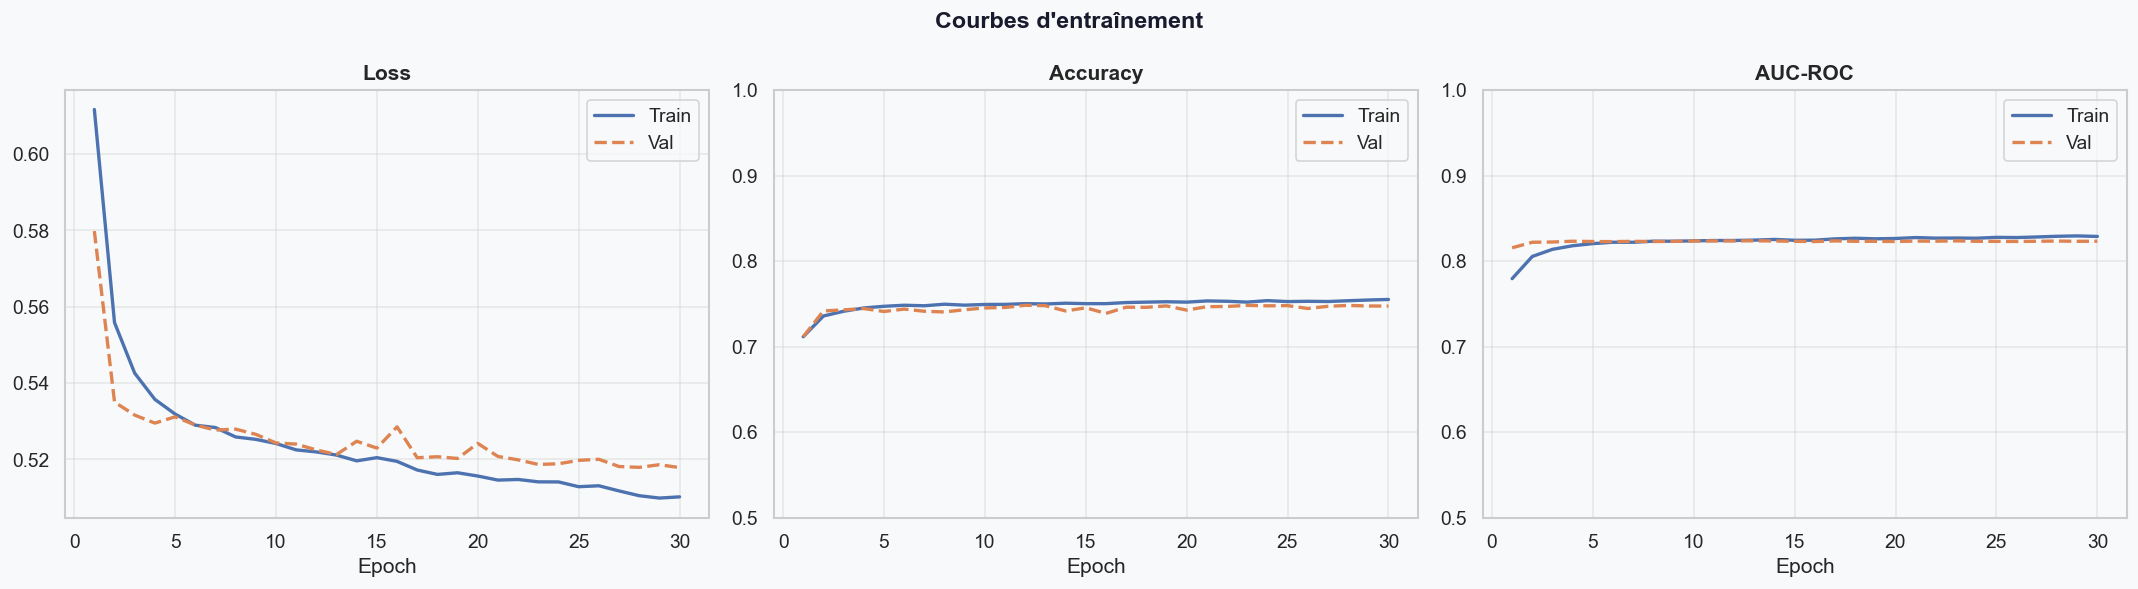

In [16]:
h = history.history
epochs_range = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle("Courbes d'entraînement", fontsize=14, fontweight='bold', color=DARK)

# Loss
axes[0].plot(epochs_range, h['loss'],     color=PALETTE[0], linewidth=2, label='Train')
axes[0].plot(epochs_range, h['val_loss'], color=PALETTE[1], linewidth=2, linestyle='--', label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(epochs_range, h['accuracy'],     color=PALETTE[0], linewidth=2, label='Train')
axes[1].plot(epochs_range, h['val_accuracy'], color=PALETTE[1], linewidth=2, linestyle='--', label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.5, 1.0); axes[1].legend(); axes[1].grid(True, alpha=0.4)

# AUC
axes[2].plot(epochs_range, h['auc'],     color=PALETTE[0], linewidth=2, label='Train')
axes[2].plot(epochs_range, h['val_auc'], color=PALETTE[1], linewidth=2, linestyle='--', label='Val')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.5, 1.0); axes[2].legend(); axes[2].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


## 6. Évaluation sur le jeu de test <a id='6'></a>

In [17]:
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred_05 = (y_prob >= 0.5).astype(int)

print('=== Évaluation avec seuil = 0.5 ===')
print(classification_report(y_test, y_pred_05,
      target_names=['Non-diabétique (0)', 'Diabétique (1)']))

# Métriques Keras sur test
results = model.evaluate(X_test, y_test, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f'  {name:15s} = {val:.4f}')


=== Évaluation avec seuil = 0.5 ===
                    precision    recall  f1-score   support

Non-diabétique (0)       0.78      0.68      0.73      6792
    Diabétique (1)       0.72      0.82      0.77      7020

          accuracy                           0.75     13812
         macro avg       0.75      0.75      0.75     13812
      weighted avg       0.75      0.75      0.75     13812

  loss            = 0.5173
  compile_metrics = 0.7496


## 7. Analyse du seuil de décision <a id='7'></a>

Meilleur seuil (max F1) = 0.43  |  F1 = 0.7758


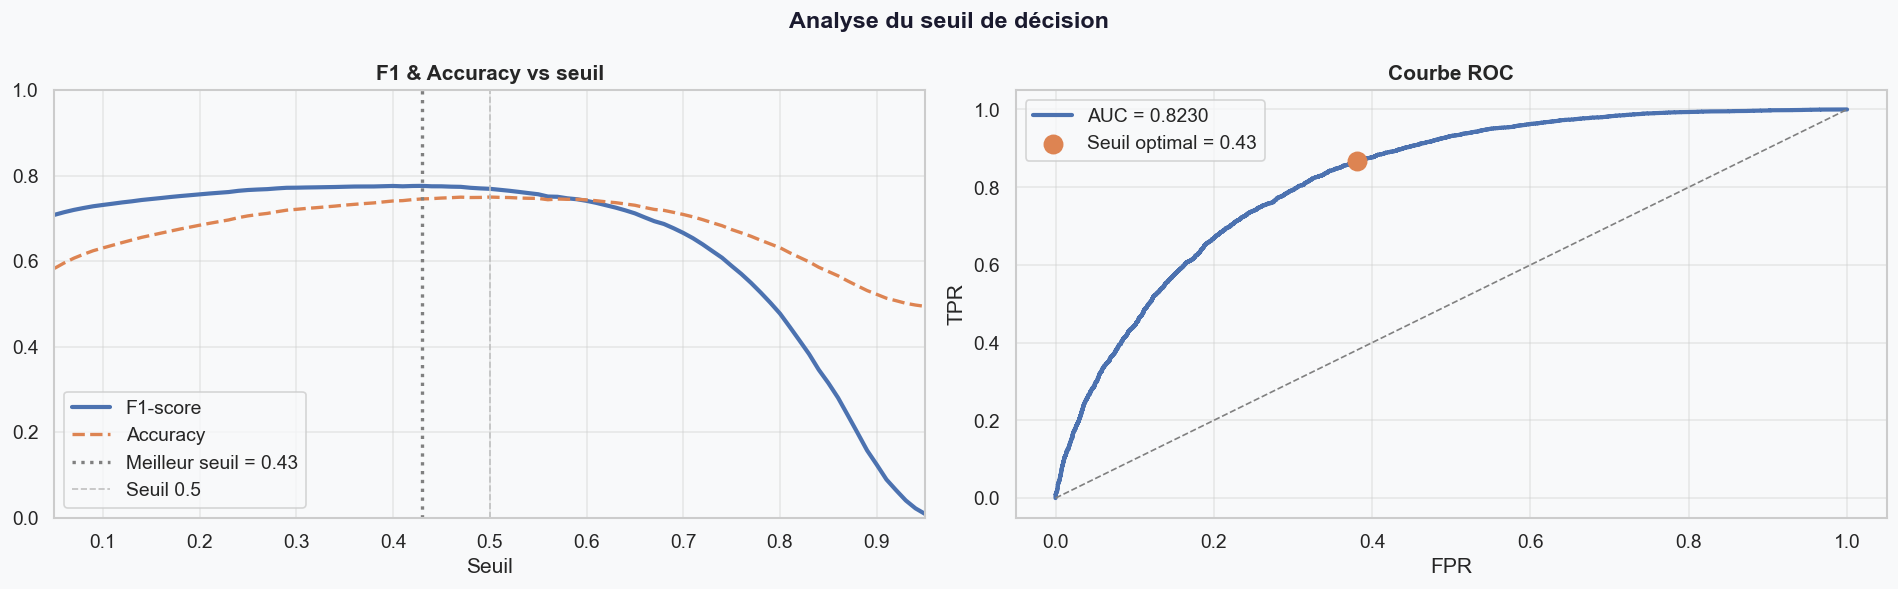


AUC-ROC = 0.8230


In [18]:
from sklearn.metrics import auc

# Trouver le seuil qui maximise le F1-score
thresholds = np.arange(0.05, 0.96, 0.01)
f1s  = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]
accs = [(y_test == (y_prob >= t).astype(int)).mean() for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)
print(f'Meilleur seuil (max F1) = {best_t:.2f}  |  F1 = {best_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
fig.suptitle('Analyse du seuil de décision', fontsize=14, fontweight='bold', color=DARK)

# F1 vs seuil
axes[0].plot(thresholds, f1s,  color=PALETTE[0], linewidth=2.5, label='F1-score')
axes[0].plot(thresholds, accs, color=PALETTE[1], linewidth=2, linestyle='--', label='Accuracy')
axes[0].axvline(best_t, color='gray', linestyle=':', linewidth=2,
                label=f'Meilleur seuil = {best_t:.2f}')
axes[0].axvline(0.5,   color='silver', linestyle='--', linewidth=1, label='Seuil 0.5')
axes[0].set_title('F1 & Accuracy vs seuil'); axes[0].set_xlabel('Seuil')
axes[0].set_xlim(0.05, 0.95); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# ROC
fpr, tpr, roc_t = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
idx_roc = np.argmin(np.abs(roc_t - best_t))
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2.5, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1)
axes[1].scatter(fpr[idx_roc], tpr[idx_roc], color=PALETTE[1], s=120, zorder=5,
                label=f'Seuil optimal = {best_t:.2f}')
axes[1].set_title('Courbe ROC'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()
print(f'\nAUC-ROC = {roc_auc:.4f}')


In [19]:
# Rapport avec le seuil optimal
y_pred_best = (y_prob >= best_t).astype(int)
print(f'=== Rapport avec seuil optimal ({best_t:.2f}) ===')
print(classification_report(y_test, y_pred_best,
      target_names=['Non-diabétique (0)', 'Diabétique (1)']))


=== Rapport avec seuil optimal (0.43) ===
                    precision    recall  f1-score   support

Non-diabétique (0)       0.82      0.62      0.71      6792
    Diabétique (1)       0.70      0.87      0.78      7020

          accuracy                           0.75     13812
         macro avg       0.76      0.74      0.74     13812
      weighted avg       0.76      0.75      0.74     13812



## 8. Matrice de confusion <a id='8'></a>

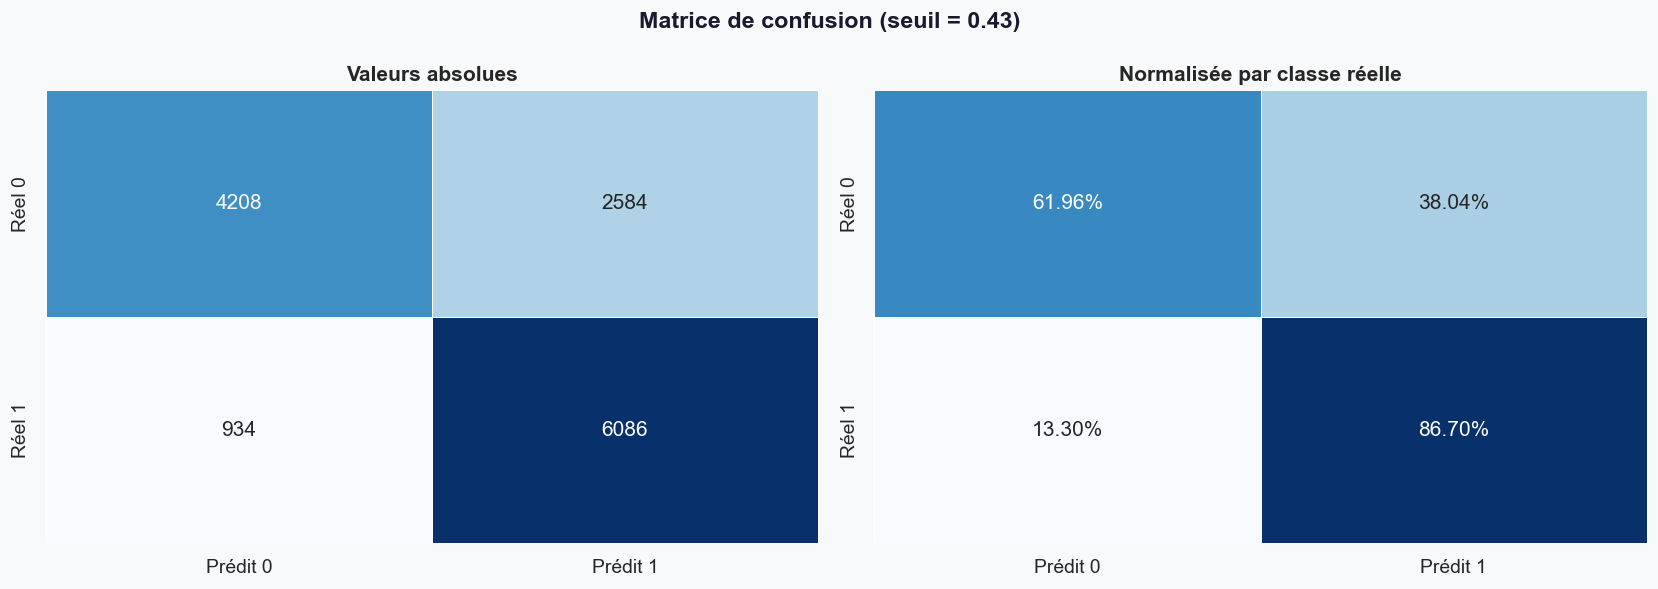

TP=6086  FP=2584  TN=4208  FN=934
Sensibilité (recall)  = 0.8670
Spécificité           = 0.6196


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle(f'Matrice de confusion (seuil = {best_t:.2f})',
             fontsize=14, fontweight='bold', color=DARK)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit 0','Prédit 1'],
            yticklabels=['Réel 0','Réel 1'],
            linewidths=0.5, cbar=False)
axes[0].set_title('Valeurs absolues')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Prédit 0','Prédit 1'],
            yticklabels=['Réel 0','Réel 1'],
            linewidths=0.5, cbar=False)
axes[1].set_title('Normalisée par classe réelle')

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print(f'Sensibilité (recall)  = {tp/(tp+fn):.4f}')
print(f'Spécificité           = {tn/(tn+fp):.4f}')


## 9. MLflow — suivi des expériences <a id='9'></a>

In [21]:
# Log des métriques finales dans MLflow
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({
        'test_roc_auc':    roc_auc,
        'test_f1_optimal': best_f1,
        'best_threshold':  best_t,
        'test_tp': float(tp), 'test_fp': float(fp),
        'test_tn': float(tn), 'test_fn': float(fn),
    })

print(f'✅ Métriques loggées dans MLflow (Run ID: {RUN_ID})')
print(f'\nPour lancer l\'interface MLflow :')
print(f'  python -m mlflow ui --backend-store-uri "sqlite:///{PROJECT_ROOT / "mlruns" / "mlflow.db"}"')
print(f'  Puis ouvrir : http://localhost:5000')
print(f'  Puis aller dans Experiments > diabetes_test1 > Training runs (dans le panneau à gauche) > {RUN_NAME} > Overview ou Model metrics (dans le panneau en haut) pour voir les détails du run')


✅ Métriques loggées dans MLflow (Run ID: e40d5489c18b4e0b8fb0ebfd038274de)

Pour lancer l'interface MLflow :
  python -m mlflow ui --backend-store-uri "sqlite:////Users/enzofraioli/Documents/Académique/CESI/FISE A4/2-Deep_Learning/Projet/BigData/mlruns/mlflow.db"
  Puis ouvrir : http://localhost:5000
  Puis aller dans Experiments > diabetes_test1 > Training runs (dans le panneau à gauche) > final_256-128_lr1e-3 > Overview ou Model metrics (dans le panneau en haut) pour voir les détails du run


In [22]:
# Afficher les runs existants
client = mlflow.tracking.MlflowClient(tracking_uri=f"sqlite:///{PROJECT_ROOT / 'mlruns' / 'mlflow.db'}")
exp = client.get_experiment_by_name('diabetes_nn')
if exp:
    runs = client.search_runs(exp.experiment_id, order_by=['metrics.test_roc_auc DESC'])
    rows = []
    for r in runs:
        rows.append({
            'Run':        r.info.run_name,
            'AUC-ROC':    r.data.metrics.get('test_roc_auc', '-'),
            'F1 optimal': r.data.metrics.get('test_f1_optimal', '-'),
            'Seuil':      r.data.metrics.get('best_threshold', '-'),
            'LR':         r.data.params.get('learning_rate', '-'),
            'Hidden':     r.data.params.get('hidden_units', '-'),
        })
    pd.DataFrame(rows)
